# Studio Favola — Risultati interattivi

Notebook di **presentazione** dei risultati: carica gli output della pipeline in `study/`
(punteggi MT, AOI del gaze, demografia) senza rifare i calcoli. Per rigenerare i dati:
`make_transcripts.py → classify_order.py → make_mapping.py → score_tests.py → analyze_balance.py → aoi_engine.py → aoi_correlations.py`.
Per rigenerare questo notebook: `scripts/make_notebook.py`.

Riferimenti: gli id **I-nn** citati nei titoli rimandano a `study/INSIGHTS.md`.
Coorte: 48 soggetti validi (27 TI = text→images, 21 IT = images→text), 96 test, 96 registrazioni gaze.

In [1]:
# Setup e caricamento dati
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

def find_study():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "aoi_scores.csv").exists():
            return base
        if (base / "study" / "aoi_scores.csv").exists():
            return base / "study"
    raise FileNotFoundError("cartella study non trovata (aoi_scores.csv)")

STUDY = find_study()

# dataset unito AOI + punteggi + demografia (una riga per registrazione/test)
df = pd.read_csv(STUDY / "aoi_scores.csv")
df["good"] = df["good"].astype(str).str.lower().eq("true")

# punteggi con fascia MT e dettagli risposte
test = pd.read_excel(STUDY / "risultati_test.xlsx", sheet_name="Punteggi")

# Palette semantica condivisa col paper (scripts/make_paper_figures.py):
# text = blu acciaio, images = terracotta; sotto-aree caption declinazioni
# delle stesse famiglie; volto = prugna; fuori-AOI = grigio neutro;
# fasce MT = rampa sequenziale monocroma (ordine di rendimento).
COL_MOD = {"text": "#3667A8", "images": "#B4653A"}
COL_GRP = {"TI": "#3667A8", "IT": "#B4653A"}  # ordine: TI text-first, IT images-first
AOI_COL = {"caption: parole": "#729ED8", "caption: immagini": "#B4653A",
           "caption: banda": "#C9D4DF", "volto": "#92589B", "fuori AOI": "#BDBDBD"}
COL_SEX = {"M": "#4D4D4D", "F": "#8C8C8C"}    # neutri: nessuno stereotipo cromatico
FASCE = ["CCRD", "PSD", "RAD", "RIDI"]
FASCE_COL = {"CCRD": "#2F4F6F", "PSD": "#5F7F9E", "RAD": "#93A9BE", "RIDI": "#C8D3DD"}

print(f"Registrazioni/test: {len(df)}  ·  Soggetti: {df.newid.nunique()}  "
      f"(TI: {df[df.grp=='TI'].newid.nunique()}, IT: {df[df.grp=='IT'].newid.nunique()})")
print(f"Registrazioni gaze di buona qualità: {df.good.sum()}/{len(df)}")

Registrazioni/test: 96  ·  Soggetti: 48  (TI: 27, IT: 21)
Registrazioni gaze di buona qualità: 87/96


## 1. La coorte (I-13, I-16)

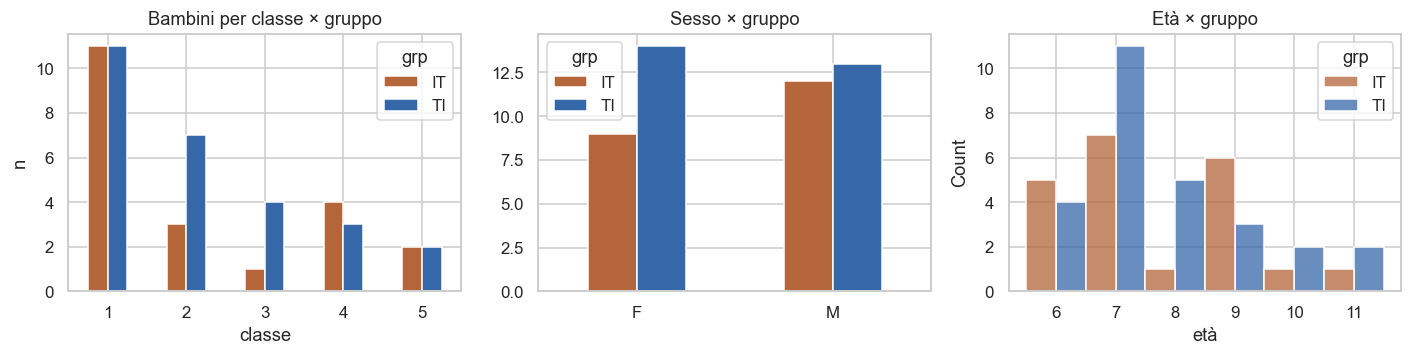

,n,M,F,eta_media
grp,,,,
IT,21,12,9,7.71
TI,27,13,14,7.78


In [2]:
# Composizione: classe x gruppo, sesso, età
kids = df.drop_duplicates("newid")[["newid", "grp", "classe", "sex", "age"]]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
ct = pd.crosstab(kids.classe, kids.grp)
ct.plot.bar(ax=axs[0], color=[COL_GRP[c] for c in ct.columns], rot=0)
axs[0].set_title("Bambini per classe × gruppo"); axs[0].set_xlabel("classe"); axs[0].set_ylabel("n")
ct2 = pd.crosstab(kids.sex, kids.grp)
ct2.plot.bar(ax=axs[1], color=[COL_GRP[c] for c in ct2.columns], rot=0)
axs[1].set_title("Sesso × gruppo"); axs[1].set_xlabel("")
sns.histplot(data=kids, x="age", hue="grp", multiple="dodge", discrete=True, palette=COL_GRP, ax=axs[2])
axs[2].set_title("Età × gruppo"); axs[2].set_xlabel("età")
plt.tight_layout(); plt.show()
kids.groupby("grp").agg(n=("newid", "count"), M=("sex", lambda s: (s=="M").sum()),
                        F=("sex", lambda s: (s=="F").sum()), eta_media=("age", "mean")).round(2)

## 2. Effetto modalità sulla comprensione (I-01) — il risultato principale

Ogni bambino ha fatto una storia in *text* e una in *images*: il confronto giusto è **appaiato**.

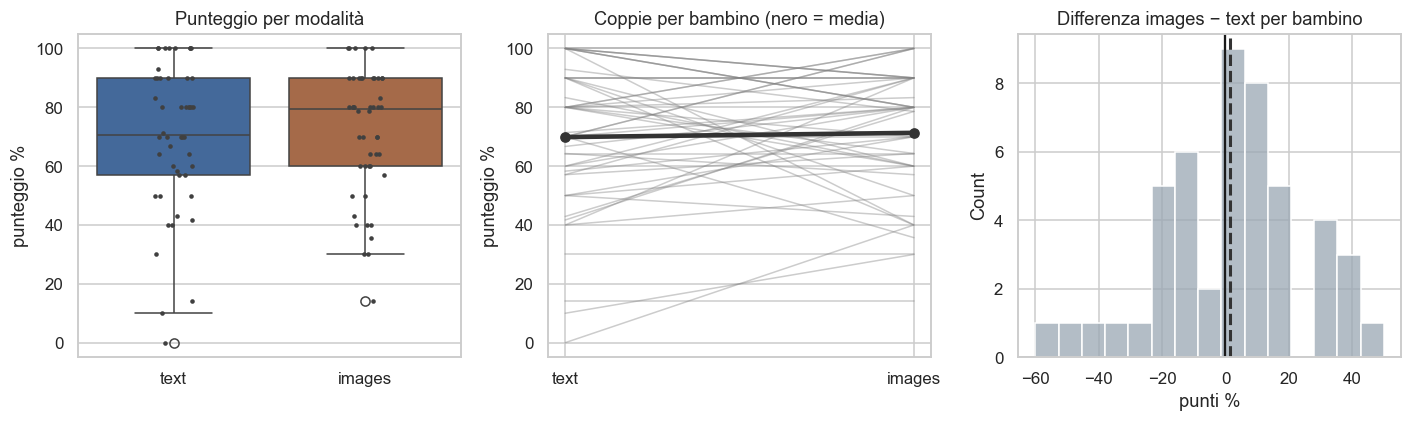

images − text: +1.4 pt (sd 23.6, n=48, t=0.42)  → nessun effetto (I-01)
meglio images: 22  ·  meglio text: 18  ·  pari: 8


In [3]:
# Confronto appaiato images - text
piv = df.pivot_table(index=["newid", "grp", "sex"], columns="mod", values="score").reset_index()
piv["diff"] = piv["images"] - piv["text"]

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(data=df, x="mod", y="score", hue="mod", order=["text", "images"],
            palette=COL_MOD, legend=False, ax=axs[0])
sns.stripplot(data=df, x="mod", y="score", order=["text", "images"], color=".25", size=3, ax=axs[0])
axs[0].set_title("Punteggio per modalità"); axs[0].set_xlabel(""); axs[0].set_ylabel("punteggio %")

for _, r in piv.iterrows():
    axs[1].plot([0, 1], [r["text"], r["images"]], color="grey", alpha=.4, lw=1)
axs[1].plot([0, 1], [piv["text"].mean(), piv["images"].mean()], color="#333333", lw=3, marker="o")
axs[1].set_xticks([0, 1], ["text", "images"]); axs[1].set_title("Coppie per bambino (nero = media)")
axs[1].set_ylabel("punteggio %")

sns.histplot(piv["diff"], bins=15, ax=axs[2], color="#9AA7B4")
axs[2].axvline(0, color="k"); axs[2].axvline(piv["diff"].mean(), color="#333333", lw=2, ls="--")
axs[2].set_title("Differenza images − text per bambino"); axs[2].set_xlabel("punti %")
plt.tight_layout(); plt.show()

d = piv["diff"].dropna()
t = d.mean() / (d.std(ddof=1) / len(d) ** 0.5)
print(f"images − text: {d.mean():+.1f} pt (sd {d.std(ddof=1):.1f}, n={len(d)}, t={t:.2f})  → nessun effetto (I-01)")
print(f"meglio images: {(d>0).sum()}  ·  meglio text: {(d<0).sum()}  ·  pari: {(d==0).sum()}")

In [4]:
# Decomposizione del disegno incrociato: effetto modalità vs effetto posizione/storia
dti = piv.loc[piv.grp == "TI", "diff"].dropna()   # images-text = S2-S1
dit = piv.loc[piv.grp == "IT", "diff"].dropna()   # images-text = S1-S2
m = (dti.mean() + dit.mean()) / 2
p = (dti.mean() - dit.mean()) / 2
se = ((dti.std(ddof=1)**2/len(dti) + dit.std(ddof=1)**2/len(dit)) ** 0.5) / 2
print(f"effetto MODALITÀ  m = {m:+.1f} pt (t≈{m/se:.2f})   [I-01]")
print(f"effetto POSIZIONE/STORIA (S2−S1) p = {p:+.1f} pt (t≈{p/se:.2f})   [I-04]")
print(f"gruppi: TI {dti.mean():+.1f} pt (n={len(dti)}) · IT {dit.mean():+.1f} pt (n={len(dit)})")

effetto MODALITÀ  m = +0.7 pt (t≈0.19)   [I-01]
effetto POSIZIONE/STORIA (S2−S1) p = +6.1 pt (t≈1.74)   [I-04]
gruppi: TI +6.8 pt (n=27) · IT -5.4 pt (n=21)


## 3. Interazione modalità × sesso (I-02) — esplorativa

I maschi rendono meglio col testo, le femmine con le immagini.

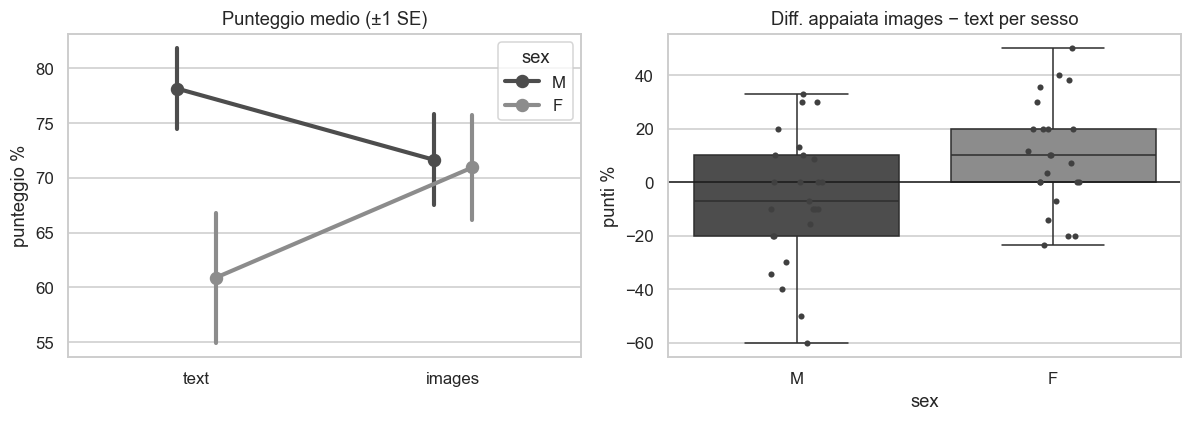

M: images − text = -6.5 pt (n=25, t=-1.35)
F: images − text = +10.1 pt (n=23, t=2.39)
→ I-02: interazione ≈17 pt (esplorativa: n piccoli, nessuna correzione per confronti multipli)


In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
sns.pointplot(data=df, x="mod", y="score", hue="sex", order=["text", "images"],
              errorbar=("se", 1), dodge=.15, ax=axs[0], palette=COL_SEX)
axs[0].set_title("Punteggio medio (±1 SE)"); axs[0].set_xlabel(""); axs[0].set_ylabel("punteggio %")

sns.boxplot(data=piv, x="sex", y="diff", hue="sex", palette=COL_SEX,
            legend=False, ax=axs[1])
sns.stripplot(data=piv, x="sex", y="diff", color=".25", size=4, ax=axs[1])
axs[1].axhline(0, color="k", lw=1)
axs[1].set_title("Diff. appaiata images − text per sesso"); axs[1].set_ylabel("punti %")
plt.tight_layout(); plt.show()

for sx in ["M", "F"]:
    d = piv.loc[piv.sex == sx, "diff"].dropna()
    t = d.mean() / (d.std(ddof=1) / len(d) ** 0.5)
    print(f"{sx}: images − text = {d.mean():+.1f} pt (n={len(d)}, t={t:.2f})")
print("→ I-02: interazione ≈17 pt (esplorativa: n piccoli, nessuna correzione per confronti multipli)")

## 4. Storie, classi e fasce MT (I-05, I-09, I-10, I-11)

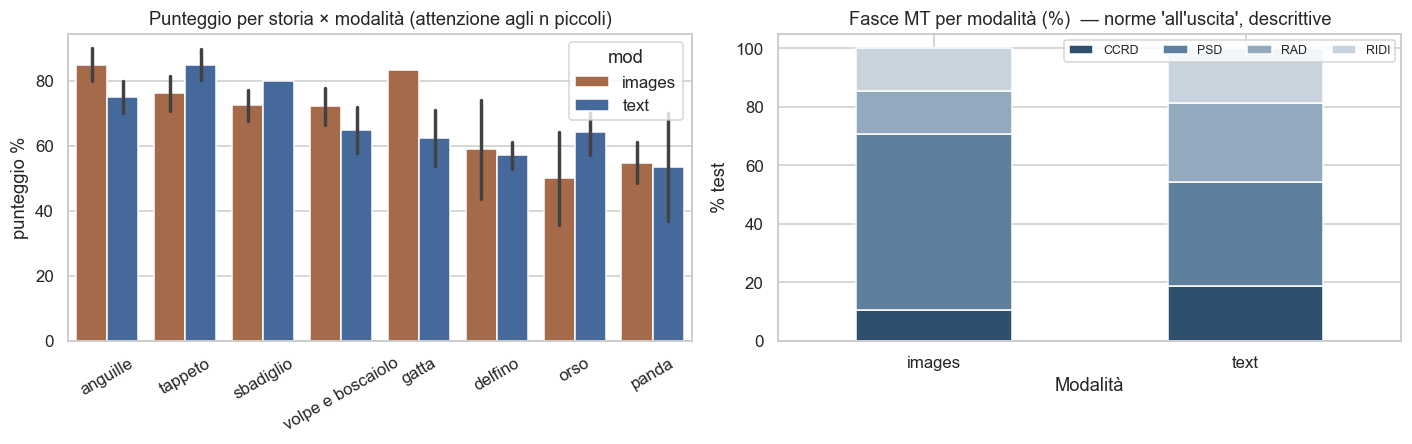

Differenza fra storie della stessa classe (S2−S1, entro bambino) [I-05]:
  classe 1: +15.0 pt (n=22, t=2.97)
  classe 2: +5.0 pt (n=10, t=0.89)
  classe 3: +7.3 pt (n=5, t=0.72)
  classe 4: -4.1 pt (n=7, t=-0.68)
  classe 5: -22.9 pt (n=4, t=-3.59)


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
order = df.groupby("storia")["score"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="storia", y="score", hue="mod", order=order, palette=COL_MOD,
            errorbar=("se", 1), ax=axs[0])
axs[0].tick_params(axis="x", rotation=30); axs[0].set_xlabel(""); axs[0].set_ylabel("punteggio %")
axs[0].set_title("Punteggio per storia × modalità (attenzione agli n piccoli)")

ft = (test.groupby(["Modalità", "Fascia MT"]).size().unstack(fill_value=0)
      .reindex(columns=FASCE).apply(lambda r: r / r.sum() * 100, axis=1))
ft.plot.bar(stacked=True, ax=axs[1], color=[FASCE_COL[f] for f in FASCE], rot=0)
axs[1].set_title("Fasce MT per modalità (%)  — norme 'all'uscita', descrittive")
axs[1].set_ylabel("% test"); axs[1].legend(title="", ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

print("Differenza fra storie della stessa classe (S2−S1, entro bambino) [I-05]:")
pos = df.assign(pos=np.where(df.storia.isin(["volpe e boscaiolo", "gatta", "delfino", "anguille"]), "S1", "S2"))
pp = pos.pivot_table(index=["newid", "classe"], columns="pos", values="score").reset_index()
pp["diff"] = pp["S2"] - pp["S1"]
for cl, g in pp.groupby("classe"):
    d = g["diff"].dropna()
    if len(d) > 1:
        t = d.mean() / (d.std(ddof=1) / len(d) ** 0.5)
        print(f"  classe {cl}: {d.mean():+.1f} pt (n={len(d)}, t={t:.2f})")

## 5. Dove guardano: AOI per modalità (I-25)

Percentuale di campioni gaze per area di interesse — metodo `web/analysis`, parametri `aoi_params.json`, calibrazione attiva.

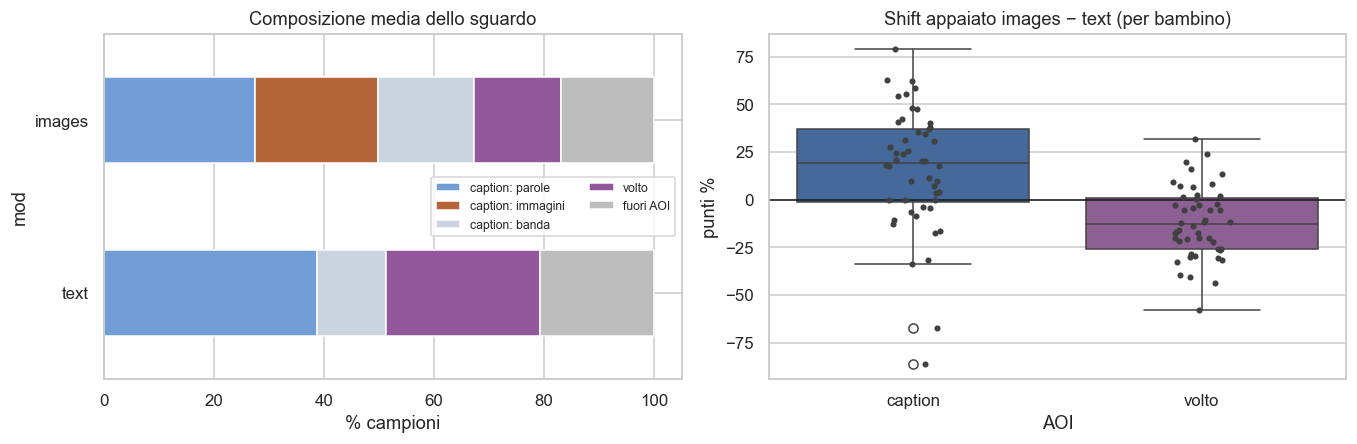

shift caption: +15.9 pt (n=48, t=3.43)
shift volto: -12.1 pt (n=48, t=-4.51)
→ I-25: con le images lo sguardo va sulle caption e lascia il volto — ma la comprensione non cambia (I-01)


In [7]:
aoi_cols = ["pct_word", "pct_image", "pct_band", "pct_face", "pct_none"]
labels = {"pct_word": "caption: parole", "pct_image": "caption: immagini", "pct_band": "caption: banda",
          "pct_face": "volto", "pct_none": "fuori AOI"}
comp = df.groupby("mod")[aoi_cols].mean().reindex(["text", "images"]).rename(columns=labels)

fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.2))
comp.plot.barh(stacked=True, ax=axs[0], color=[AOI_COL[c] for c in comp.columns])
axs[0].set_title("Composizione media dello sguardo"); axs[0].set_xlabel("% campioni")
axs[0].legend(fontsize=8, ncol=2)

pv = df.pivot_table(index="newid", columns="mod", values=["pct_caption", "pct_face"])
sh = pd.DataFrame({
    "caption": pv["pct_caption"]["images"] - pv["pct_caption"]["text"],
    "volto":   pv["pct_face"]["images"] - pv["pct_face"]["text"],
}).melt(var_name="AOI", value_name="diff")
sns.boxplot(data=sh, x="AOI", y="diff", hue="AOI", palette=["#3667A8", "#92589B"], legend=False, ax=axs[1])
sns.stripplot(data=sh, x="AOI", y="diff", color=".25", size=4, ax=axs[1])
axs[1].axhline(0, color="k", lw=1)
axs[1].set_title("Shift appaiato images − text (per bambino)"); axs[1].set_ylabel("punti %")
plt.tight_layout(); plt.show()

for name, s in [("caption", sh[sh.AOI=="caption"]["diff"].dropna()), ("volto", sh[sh.AOI=="volto"]["diff"].dropna())]:
    t = s.mean() / (s.std(ddof=1) / len(s) ** 0.5)
    print(f"shift {name}: {s.mean():+.1f} pt (n={len(s)}, t={t:.2f})")
print("→ I-25: con le images lo sguardo va sulle caption e lascia il volto — ma la comprensione non cambia (I-01)")

## 6. AOI ↔ punteggio (I-26, I-27, I-28)

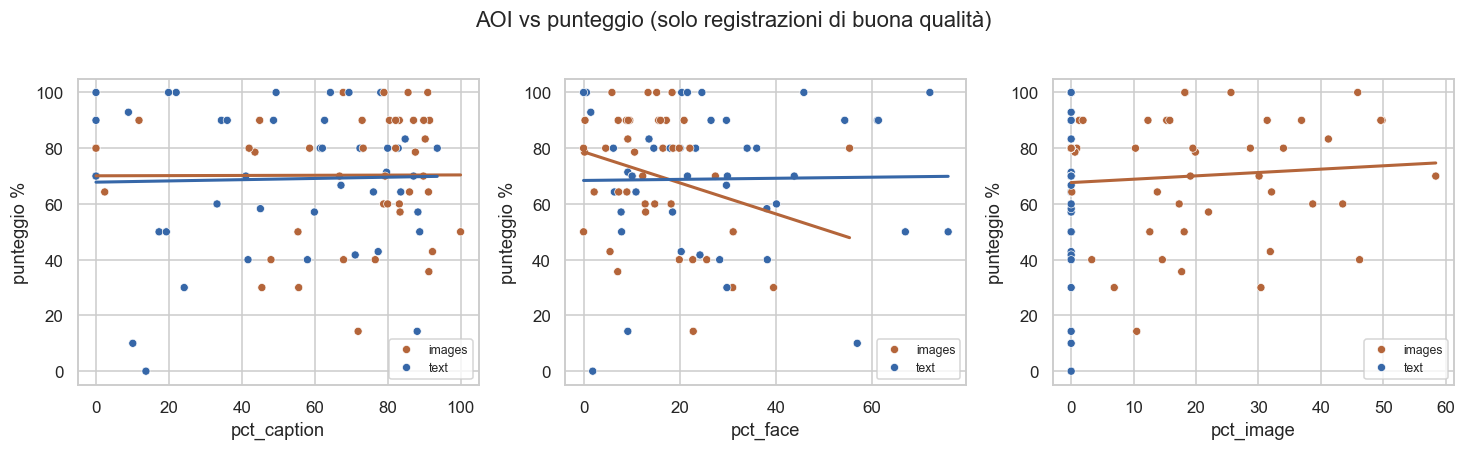

gruppo,tutti,text,images,M,F
AOI,,,,,
pct_caption,+0.02,+0.03,+0.00,-0.04,+0.06
pct_eyes,-0.05,-0.07,+0.02,+0.04,-0.08
pct_face,-0.08,+0.02,-0.28,-0.05,-0.08
pct_image,+0.06,+nan,+0.09,-0.08,+0.18
pct_mouth,-0.04,-0.01,-0.07,-0.13,+0.07
pct_none,+0.03,-0.04,+0.11,+0.07,-0.01
pct_word,+0.01,+0.00,+0.06,+0.06,-0.04


In [8]:
g = df[df.good]
mets = ["pct_caption", "pct_word", "pct_image", "pct_face", "pct_mouth", "pct_eyes", "pct_none"]

fig, axs = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, met in zip(axs, ["pct_caption", "pct_face", "pct_image"]):
    sns.scatterplot(data=g, x=met, y="score", hue="mod", palette=COL_MOD, s=28, ax=ax)
    for mod, gg in g.groupby("mod"):
        gg = gg.dropna(subset=[met, "score"])
        if len(gg) > 2 and gg[met].std() > 0:
            z = np.polyfit(gg[met], gg["score"], 1)
            xs = np.linspace(gg[met].min(), gg[met].max(), 20)
            ax.plot(xs, np.polyval(z, xs), color=COL_MOD[mod], lw=2)
    ax.set_ylabel("punteggio %"); ax.legend(fontsize=8)
plt.suptitle("AOI vs punteggio (solo registrazioni di buona qualità)", y=1.02)
plt.tight_layout(); plt.show()

rows = []
for met in mets:
    for label, gg in [("tutti", g), ("text", g[g["mod"]=="text"]), ("images", g[g["mod"]=="images"]),
                      ("M", g[g.sex=="M"]), ("F", g[g.sex=="F"])]:
        gg = gg.dropna(subset=[met, "score"])
        if len(gg) > 2 and gg[met].std() > 0:
            r = gg[met].corr(gg["score"])
            n = len(gg)
            t = r * ((n - 2) / (1 - r * r)) ** 0.5
            rows.append({"AOI": met, "gruppo": label, "r": round(r, 2), "n": n, "t": round(t, 2)})
corr = pd.DataFrame(rows).pivot(index="AOI", columns="gruppo", values="r")[["tutti", "text", "images", "M", "F"]]
corr.style.background_gradient(cmap="RdBu_r", vmin=-.5, vmax=.5).format("{:+.2f}")

## 7. Analisi puntuale: lo sguardo nel momento dell'informazione (I-30…I-33)

Per ogni domanda "puntuale" (90 su 94) è definita la finestra temporale in cui la
narrazione dà l'informazione necessaria a rispondere (`question_windows.json`).
Qui: quota di sguardo sulle **parole-ancora** dentro la finestra vs correttezza
della risposta. Regole: soglia ≥5 campioni in finestra, bianche = errate,
padding −1.0/+1.5 s (sensitivity −0.5/+1.0 e −2.0/+3.0: risultati identici,
vedi `scripts/question_gaze.py`).

Osservazioni incluse: 920  ·  corrette: 69%  ·  bianche (errate): 46


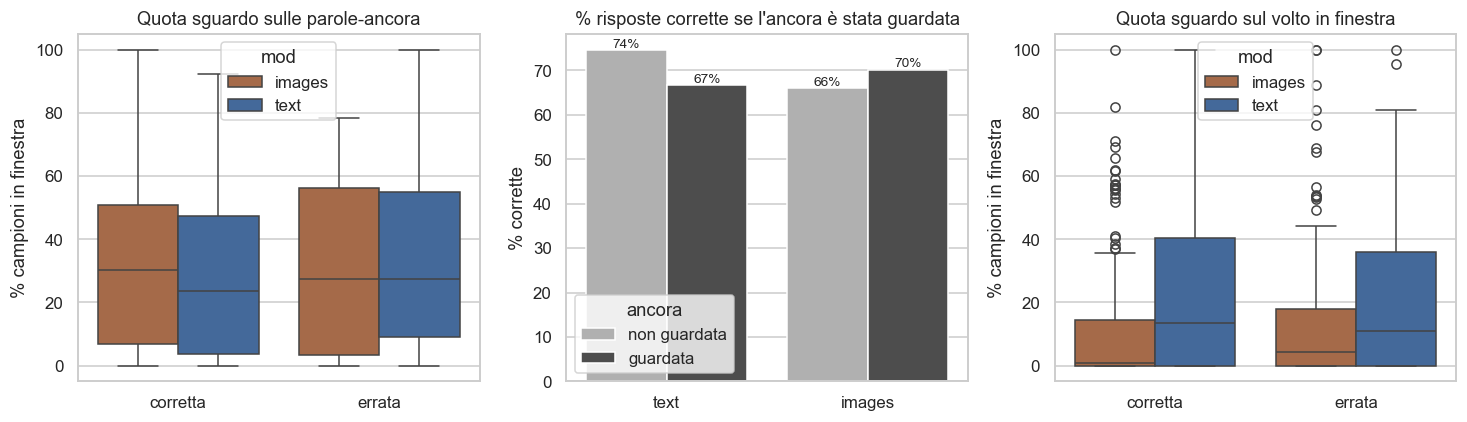

tutti : ancora corrette 28.6% vs errate 31.4%  (diff -2.9, t=-1.60)
text  : ancora corrette 26.6% vs errate 32.1%  (diff -5.5, t=-2.24)
images: ancora corrette 30.6% vs errate 30.7%  (diff -0.2, t=-0.07)
→ I-31: guardare l'informazione mentre viene narrata NON predice la correttezza


In [9]:
qg = pd.read_csv(STUDY / "question_gaze.csv")
qg = qg[qg.incluso == 1].copy()
qg["esito"] = np.where(qg.correct == 1, "corretta", "errata")
print(f"Osservazioni incluse: {len(qg)}  ·  corrette: {qg.correct.mean()*100:.0f}%  ·  bianche (errate): {qg.blank.sum()}")

fig, axs = plt.subplots(1, 3, figsize=(13.5, 4))
sns.boxplot(data=qg, x="esito", y="pct_anchor", hue="mod", palette=COL_MOD, ax=axs[0])
axs[0].set_title("Quota sguardo sulle parole-ancora"); axs[0].set_ylabel("% campioni in finestra"); axs[0].set_xlabel("")

acc = qg.groupby(["mod", "any_anchor"])["correct"].agg(["mean", "count"]).reset_index()
acc["% corrette"] = acc["mean"] * 100
acc["ancora"] = np.where(acc.any_anchor == 1, "guardata", "non guardata")
sns.barplot(data=acc, x="mod", y="% corrette", hue="ancora", order=["text", "images"],
            palette={"guardata": "#4D4D4D", "non guardata": "#B0B0B0"}, ax=axs[1])
axs[1].set_title("% risposte corrette se l'ancora è stata guardata"); axs[1].set_xlabel("")
for c in axs[1].containers:
    axs[1].bar_label(c, fmt="%.0f%%", fontsize=9)

sns.boxplot(data=qg, x="esito", y="pct_face", hue="mod", palette=COL_MOD, ax=axs[2])
axs[2].set_title("Quota sguardo sul volto in finestra"); axs[2].set_ylabel("% campioni in finestra"); axs[2].set_xlabel("")
plt.tight_layout(); plt.show()

def welch(a, b):
    a, b = a.dropna(), b.dropna()
    return (a.mean() - b.mean()) / (a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b)) ** 0.5

for mod in ["tutti", "text", "images"]:
    q = qg if mod == "tutti" else qg[qg["mod"] == mod]
    ok, ko = q[q.correct == 1]["pct_anchor"], q[q.correct == 0]["pct_anchor"]
    print(f"{mod:6}: ancora corrette {ok.mean():.1f}% vs errate {ko.mean():.1f}%  "
          f"(diff {ok.mean()-ko.mean():+.1f}, t={welch(ok, ko):+.2f})")
print("→ I-31: guardare l'informazione mentre viene narrata NON predice la correttezza")

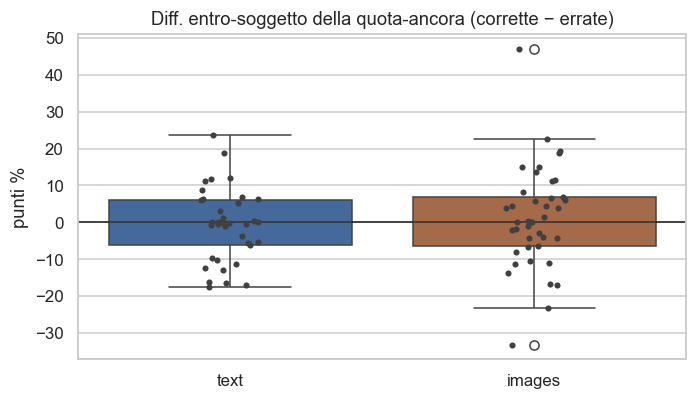

images: n=41  diff media=+1.2 pt  t=+0.55
text  : n=37  diff media=-0.7 pt  t=-0.44
→ I-32: il segnale negativo del text a livello di osservazione (t=-2.43) sparisce entro-soggetto:
  era un effetto TRA bambini (chi si aggrappa al testo sbaglia di più in generale), non momento-per-momento


In [10]:
# Controllo anti pseudo-replicazione: differenza entro-soggetto (corrette - errate)
recs = []
for (nid, mod), g in qg.groupby(["newid", "mod"]):
    ok, ko = g[g.correct == 1]["pct_anchor"].dropna(), g[g.correct == 0]["pct_anchor"].dropna()
    if len(ok) and len(ko):
        recs.append({"newid": nid, "mod": mod, "diff": ok.mean() - ko.mean()})
sub = pd.DataFrame(recs)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.boxplot(data=sub, x="mod", y="diff", hue="mod", order=["text", "images"], palette=COL_MOD, legend=False, ax=ax)
sns.stripplot(data=sub, x="mod", y="diff", order=["text", "images"], color=".25", size=4, ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_title("Diff. entro-soggetto della quota-ancora (corrette − errate)")
ax.set_ylabel("punti %"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

for mod, g in sub.groupby("mod"):
    d = g["diff"]
    t = d.mean() / (d.std(ddof=1) / len(d) ** 0.5)
    print(f"{mod:6}: n={len(d):2}  diff media={d.mean():+.1f} pt  t={t:+.2f}")
print("→ I-32: il segnale negativo del text a livello di osservazione (t=-2.43) sparisce entro-soggetto:")
print("  era un effetto TRA bambini (chi si aggrappa al testo sbaglia di più in generale), non momento-per-momento")

## 8. Qualità delle registrazioni gaze (I-29)

In [11]:
bad = df[~df.good][["newid", "pid", "storia", "mod", "n", "dur", "hz", "score"]]
print(f"{len(bad)} registrazioni sotto soglia (hz<5 o durata<40s) — I-25/I-26 non cambiano con/senza")
bad.sort_values(["newid", "storia"])

9 registrazioni sotto soglia (hz<5 o durata<40s) — I-25/I-26 non cambiano con/senza


,newid,pid,storia,mod,n,dur,hz,score
6,IT04,F11,tappeto,text,18,8.9,2.0,100.0
27,IT14,F23,volpe e boscaiolo,images,119,50.5,2.4,80.0
34,IT18,F32,tappeto,text,256,67.3,3.8,90.0
36,IT19,F33,tappeto,text,137,23.3,5.9,60.0
50,TI05,B5,tappeto,images,195,50.8,3.8,70.0
51,TI05,B5,volpe e boscaiolo,text,130,61.4,2.1,70.0
54,TI07,B7,tappeto,images,261,67.1,3.9,90.0
73,TI16,B16,sbadiglio,images,88,8.7,10.1,60.0
84,TI22,B23,tappeto,images,1,67.2,0.0,100.0


## 9. Esplorazione interattiva

Filtra per gruppo, classe e sesso (richiede ipywidgets; in VS Code funziona out-of-the-box).

In [12]:
try:
    from ipywidgets import interact, Dropdown

    def esplora(gruppo="tutti", classe="tutte", sesso="tutti"):
        q = df.copy()
        if gruppo != "tutti": q = q[q.grp == gruppo]
        if classe != "tutte": q = q[q.classe.astype(str) == classe]
        if sesso != "tutti": q = q[q.sex == sesso]
        if q.empty:
            print("nessun dato con questi filtri"); return
        fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
        sns.boxplot(data=q, x="mod", y="score", hue="mod", order=["text", "images"],
                    palette=COL_MOD, legend=False, ax=axs[0])
        sns.stripplot(data=q, x="mod", y="score", order=["text", "images"], color=".25", size=4, ax=axs[0])
        axs[0].set_title(f"Punteggi (n={len(q)})"); axs[0].set_ylabel("punteggio %"); axs[0].set_xlabel("")
        comp = q.groupby("mod")[aoi_cols].mean().reindex(["text", "images"]).rename(columns=labels)
        comp.plot.barh(stacked=True, ax=axs[1], color=[AOI_COL.get(c, "#BDBDBD") for c in comp.columns], legend=False)
        axs[1].set_title("AOI medie"); axs[1].set_xlabel("% campioni")
        plt.tight_layout(); plt.show()
        print(q.groupby("mod")["score"].agg(["count", "mean", "std"]).round(1))

    interact(esplora,
             gruppo=Dropdown(options=["tutti", "TI", "IT"], description="gruppo"),
             classe=Dropdown(options=["tutte"] + sorted(df.classe.astype(str).unique()), description="classe"),
             sesso=Dropdown(options=["tutti", "M", "F"], description="sesso"))
except ImportError:
    print("ipywidgets non disponibile: usa i filtri modificando le celle sopra")

interactive(children=(Dropdown(description='gruppo', options=('tutti', 'TI', 'IT'), value='tutti'), Dropdown(d…

## 10. Insights completi

Il registro completo (con etichette di solidità e id citabili) è in `study/INSIGHTS.md`:

In [13]:
from IPython.display import Markdown
Markdown((STUDY / "INSIGHTS.md").read_text(encoding="utf-8"))

# Insights — Studio Favola

> Lista viva di tutto ciò che è emerso dalle analisi, **inclusi i risultati non significativi** (sono risultati anche loro). Ogni insight ha un id stabile (I-nn) per poterlo citare, i numeri a supporto e un'etichetta di solidità: **[SIG]** significativo (|t|≥2) · **[NS]** non significativo · **[ESP]** esplorativo, da confermare · **[DES]** descrittivo, nessun test · **[MET]** metodologico/qualità dati.
>
> Coorte di riferimento: 48 soggetti validi (27 TI, 21 IT), 96 test, 48 coppie text/images appaiate. Scoring MT con `chiave_derivata.json` **nella versione finale** (post correzioni I-34 e I-43). Analisi del 9–10 luglio 2026; numeri riallineati alla chiave finale il 21 luglio 2026 (stessi script; i valori riportati qui sotto coincidono con quelli del paper).

## A. Effetti sperimentali

- **I-01 [NS] La modalità delle caption (text vs images) non ha effetto sulla comprensione.** Confronto appaiato entro bambino (n=48, chiave finale post-correzioni I-34 e I-43): images−text = **+1.4 pt** (sd 23.6, t(47)=0.42). 22 bambini meglio con images, 18 con text, 8 pari. Decomposizione del disegno incrociato: effetto modalità puro **m = +0.7 pt (t≈0.19)**. Robusto all'esclusione di B5/TI05. Formalizzato dal TOST (I-46): equivalenza entro ±7.5 pt. È il risultato principale dello studio.

- **I-02 [ESP] Interazione modalità × sesso: i maschi rendono meglio col testo, le femmine con le immagini.** Diff appaiata images−text: maschi **−6.5 pt** (n=25, t=−1.35), femmine **+10.1 pt** (n=23, t=2.39); interazione ≈ 16.6 pt (t Welch=2.58). Spiegherebbe perché l'effetto medio (I-01) è nullo. Cautela: analisi esplorativa, n piccoli, nessuna correzione per confronti multipli, e il gruppo F femmine è leggermente sbilanciato verso TI (14 TI vs 9 IT). **Ipotesi da verificare con l'analisi AOI del gaze** (guardano cose diverse?).

- **I-03 [NS] L'ordine di somministrazione (TI vs IT) non ha effetto dimostrabile.** Media per bambino: IT 74.1% vs TI 67.9% → **+6.2 pt** (t Welch=1.08). La differenza è concentrata nella classe 1ª (TI 63.2% vs IT 77.3%, n=11+11), quindi è più compatibile con una differenza tra i gruppi di bambini che con un effetto dell'ordine. NB: l'ordine coincide col percorso/postazione prevalente, non è separabile da esso.

- **I-04 [NS] Effetto posizione/storia (seconda vs prima storia): +6.1 pt (t≈1.74).** Dalla decomposizione del disegno incrociato. Posizione e identità della storia non sono separabili (ogni storia è sempre nella stessa posizione).

- **I-05 [SIG] Le due storie della stessa classe non sono equivalenti in difficoltà.** Sulla coorte valida (48, chiave finale): in classe 1ª il tappeto è più facile della volpe di **+15.0 pt** (n=22, t=2.97, p<.01); stesso segno in 2ª (+5.0, t=0.89 [NS]). In classe 5ª l'orso è più difficile delle anguille di **−22.9 pt** (n=4, t=−3.59, significativo pur col n minimo). Classe 3ª: sbadiglio−gatta +7.3 (n=5, t=0.72 [NS]; il segno si è invertito con la chiave finale rispetto alla prima stesura); classe 4ª: panda−delfino −4.1 (n=7, t=−0.68 [NS]). Conseguenza: ogni confronto di modalità DEVE essere appaiato entro bambino (com'è, per costruzione del disegno).

- **I-06 [NS] Sesso (effetto principale): maschi 74.9% vs femmine 65.9% (+9.0 pt, t Welch=1.54).** Media dei due test per bambino (25 M, 23 F).

- **I-07 [NS] Età: nessuna relazione lineare col punteggio** (r=−0.09, n=48). L'età coincide quasi perfettamente con la classe, quindi è confusa con la prova. Curiosità non monotona: i 7-enni sono il gruppo migliore (80.0%, n=18), i 6-enni il peggiore (60.0%, n=9) — riflette in gran parte la coppia classe/prova (i 7-enni di classe 2ª fanno le prove più facili).

- **I-08 [NS] Sessione (mattina vs pomeriggio): −1.7 pt (t=−0.34).** Completamente confusa con la composizione delle classi (pomeriggio ≈ solo classe 1ª).

## B. Osservazioni descrittive

- **I-09 [DES] Gradiente di difficoltà tra le prove** (media %, entrambe le modalità, coorte valida n=48, chiave finale): tappeto 80.0 (n=32) ≈ anguille 80.0 (n=4) > sbadiglio 74.0 (n=5) > volpe 68.1 (n=32) > gatta 66.7 (n=5) > delfino 58.2 (n=7) > orso 57.1 (n=4) > panda 54.1 (n=7). Le prove "indagine approfondita" MT (14 domande: delfino, panda, orso) sono sistematicamente più dure delle prove d'ingresso.

- **I-10 [DES] Fasce MT per modalità** (prove applicate all'uscita → riferimento descrittivo, non normativo): text 19% CCRD / 35% PSD / 27% RAD / 19% RIDI; images 10% / 60% / 15% / 15%. Con images le code (eccellenti e in difficoltà) si assottigliano e la massa si concentra su PSD; distribuzioni comunque compatibili.

- **I-11 [DES] Rendimento per classe**: 2ª la migliore (82.5%), 1ª 70.2%, 5ª 65.9%, 3ª 63.3%, 4ª la più in difficoltà (56.2%). Non confrontabili direttamente: prove diverse per classe.

- **I-12 [DES] Postazione/PC (bene 67.9% vs fra 72.0%)**: rispecchia in larga parte la differenza TI/IT (I-03); nessun segnale attribuibile all'hardware.

- **I-13 [DES] Demografia bilanciata tra i gruppi**: TI 13M/14F, età media 7.8; IT 12M/9F, età media 7.7 (range 6–11 entrambi). Il disegno non ha introdotto distorsioni demografiche rilevanti.

## C. Metodologia e qualità dati

- **I-14 [MET] Il foglio "Risposte" di test.xlsx è la chiave MT ufficiale, ma NON vale per i fogli adattati somministrati.** Verificato sulle guide MT originali (8/8 storie identiche). I fogli adattati hanno: opzioni ruotate (Volpe Q4; Tappeto Q2/Q4/Q5/Q7/Q9), domande rinumerate (Sbadiglio Q2↔Q3). Per lo scoring vale `chiave_derivata.json`. Un'ambiguità (Sbadiglio Q6) è stata risolta a favore della chiave MT ("mette la testa fuori dal finestrino" = c).

- **I-15 [MET] L'ordine reale di somministrazione va letto dai timestamp gaze, non dal prefisso dell'id né dalla postazione.** Un bambino su 48 (F12→TI27) ha l'ordine invertito rispetto al prefisso; 12 bambini hanno cambiato postazione tra le due storie; la narratrice è unica, quindi nessun confondimento narratore.

- **I-16 [MET] Bilanciamento classe × ordine imperfetto**: 1ª 11/11, 4ª 3/4, 5ª 2/2 ok; **2ª sbilanciata (7 TI / 3 IT)** e **3ª (4 TI / 1 IT)**. Da tenere presente in ogni analisi che aggreghi per classe.

- **I-17 [MET] Esclusioni (8 soggetti, post fusione I-51)**: F1 (nessun gaze), F2, F3, F10, F25 (gaze parziale) → ordine non verificabile; F6 (=F4 nel gaze, images+images) e F35 (text+text) → somministrazione anomala; B19 assente. Coorte finale 48.

- **I-18 [MET] Incidenti di raccolta dati risolti**: la stessa registrazione attribuita a due bambini in due casi (eels 10:17 → F7, carpet 10:18 → b6; originali in `_scartati/`), refuso `` `F4 `` nel participantId, excel registrazioni rigenerato (104 registrazioni valide).

- **I-19 [MET] Qualità gaze da considerare nell'analisi AOI**: B5/TI05 con entrambe le registrazioni degradate (61s/130 campioni; abort a 50.8s), F10 con tracking ~1 Hz (escluso comunque), F3 con video probabilmente riavviato (167s). Frequenza attesa ~10 Hz.

- **I-20 [MET, risolto da I-51] Il paper trail aveva due buchi speculari**: F4 con gaze ma senza fogli/demo, F6 con fogli/demo ma senza gaze → erano lo stesso bambino (fusione I-51). Resta: F1 con i test ma nessun gaze (registrazione persa/mai salvata); demo.csv con una riga duplicata (F35, valori identici, innocua).

## E. Gaze / AOI (analisi aggregata, metodo web/analysis con parametri concordati in `aoi_params.json`)

- **I-25 [SIG] La modalità images sposta massicciamente l'attenzione visiva.** Confronto appaiato entro bambino (n=48): con le images la quota di tempo sulle caption sale di **+15.9 pt** (t=3.43) e quella sul volto scende di **−12.1 pt** (t=−4.51); cala il tempo sulle parole-testo (−11.4, t=−3.33), sulla bocca (−3.5, t=−2.52) e sugli occhi (−3.6, t=−2.96); invariato il fuori-AOI (ns). Medie: text → caption 51.4% / face 28.0% / none 20.7%; images → caption 67.2% (di cui 22.5% sulle parole-immagine) / face 15.9% / none 16.9%. Lo shift è simile nei due sessi (caption: M +13 pt, F +21 pt). **Insieme a I-01: la modalità cambia moltissimo dove si guarda, ma non quanto si capisce.**

- **I-26 [NS] Le AOI aggregate non predicono il punteggio.** Correlazioni AOI→punteggio tutte ≈ 0 (|r|≤0.08 sulle 87 registrazioni di buona qualità; |r|≤0.12 su tutte le 96). Quanto tempo si passa su caption/volto/parole non correla con la comprensione.

- **I-27 [ESP] In modalità images, più tempo sul volto → punteggio leggermente peggiore** (r=−0.28, n=43, t=−1.84, n.s.). Unico segnale sopra il rumore nelle correlazioni aggregate; da riverificare nel lavoro puntuale.

- **I-28 [ESP] Nelle femmine, più tempo sulle parole-immagine → punteggio leggermente migliore** (r=+0.18, n=42, n.s.). Direzione coerente con I-02, ma debole.

- **I-29 [MET] 9 registrazioni gaze di bassa qualità** (freq <5 Hz o durata <40s): TI05 ×2 (2.1/3.8 Hz), TI07 (3.9 Hz), IT18 (3.8 Hz), IT14 (2.4 Hz), IT19 (troncata a 23s), TI16 sbadiglio/images e IT04 tappeto/text (troncate a ~9s), e **TI22 tappeto/images con 1 solo campione (inutilizzabile)**. I risultati I-25/I-26 non cambiano includendole o escludendole.

## F. Analisi puntuale (sguardo nel momento dell'informazione — `question_gaze.csv`)

- **I-30 [MET] Dataset puntuale costruito.** 90 domande puntuali con finestra temporale dell'informazione per variante (`question_windows.json`, 218 finestre, match ≥0.94; orso Q12 recuperata: "pinnipede" riconosciuto come "pesce" ma frase presente e ancorata). 989 osservazioni soggetto×domanda, 920 incluse (soglia ≥5 campioni in finestra); bianche = errate (tempo illimitato); padding primario −1.0/+1.5 s con sensitivity −0.5/+1.0 e −2.0/+3.0 (risultati identici su tutti e tre).

- **I-31 [NS] Guardare le parole-ancora nel momento dell'informazione NON predice la correttezza della risposta.** Quota-ancora nelle risposte corrette 28.6% vs errate 31.4% (diff −2.9 pt, t=−1.60); aggregato per soggetto n.s.; "ancora guardata almeno una volta" OR=0.91. Robusto al padding e confermato dal GEE con cluster per soggetto (I-47). Il canale uditivo sembra sufficiente: chi non guarda la caption nel momento chiave non risponde peggio.

- **I-32 [ESP] (attenzione all'interpretazione) In modalità text l'associazione negativa osservata a livello di domanda (corrette 26.6% vs errate 32.1% di quota-ancora, t=−2.24) NON regge al controllo entro-soggetto (−0.7 pt, t=−0.44, n=37).** È quindi un effetto tra-soggetti: i bambini che in text fissano di più le parole-caption nei momenti chiave tendono a sbagliare di più in generale (possibile marcatore di lettori/ascoltatori più deboli che si aggrappano al testo), non un danno momento-per-momento.

- **I-33 [ESP] In modalità images, tendenze deboli ma coerenti con I-27:** guardare l'ancora non danneggia (OR=1.21, n.s.; entro-soggetto +1.2 pt, t=+0.55) e guardare il **volto** nel momento dell'informazione si associa a più errori (9.7% nelle corrette vs 13.8% nelle errate, t=−1.99, n.s.).

## G. Analisi estese (10 luglio 2026 — scripts: temporal_word_analysis, question_extra, subject_profiles, stats_robustness, aoi_sensitivity)

- **I-34 [MET] Correzione chiave Sbadiglio Q2/Q3 (ordine di trascrizione).** L'item analysis ha rivelato p=0.00 su entrambe con la chiave "a numerazione stampata": il foglio adattato stampa la Q3 sopra la Q2 e la trascrizione in test.xlsx segue l'ordine visivo, quindi le colonne 2/3 corrispondono alla numerazione MT (2=sorellina→b, 3=donna→a). Chiave e finestre corrette e pipeline rilanciata: i risultati principali non cambiano (I-01 passa da +1.0 a +1.6 pt, sempre n.s.).

- **I-35 [SIG] L'attenzione alle caption non si esaurisce col tempo — con le immagini cresce.** Time-course per quartile del video (solo registrazioni buone): text ≈ stabile (48→51%), images cresce (Q1 62.9% → Q4 69.8%; Q4−Q1 entro bambino **+6.9 pt, t=+2.87**). Il volto ha un picco nel primo quartile (novità: text 35%, images 23.5%) e poi cala. Le immagini non sono una novità che stanca: reggono per tutto il video.

- **I-36 [SIG] Le parole-immagine vengono guardate molto più spesso delle parole-testo.** Quota di parole guardate almeno una volta: **56%** delle parole-immagine vs 32% delle parole-testo (in images) e 35% (in text). La latenza della prima occhiata è simile (mediana 0.6–0.8 s). È il meccanismo dietro I-25: le immagini non attirano più in fretta, attirano più spesso.

- **I-37 [NS] Le immagini non causano "ping-pong" attentivo.** Switch volto↔caption: text 15.9/min vs images 13.1/min (appaiato −3.3/min, t=−1.65): semmai con le immagini lo sguardo è più stabile.

- **I-38 [DES] Reading-along in text**: il 48.9% del tempo-caption è speso vicino all'ultima parola comparsa (sd 19, n=40 registrazioni; quota >50% in 22/40 registrazioni) — circa metà dei bambini "insegue" la scrittura mentre ascolta; grande variabilità individuale, potenziale proxy dell'abilità di lettura.

- **I-39 [DES] Densità di parole-immagine e resa della storia**: r=+0.51 tra % di parole-immagine e punteggio in modalità images (n=8 storie, puramente descrittivo). L'orso — la storia con meno immagini (15.6%) — è la storia con lo svantaggio images più netto (−14.2 pt).

- **I-40 [NS] Nessuna interazione modalità × tipo di domanda (esplicite vs inferenziali).** Classificazione MT-template sulle 4 storie a 10 domande (da verificare sul manuale): entro bambino, esplicite +3.8 pt con images (t=0.67), inferenziali −2.5 (t=−0.50).

- **I-41 [ESP] Congruenza video→foglio, direzione giusta ma non conclusiva.** Le domande con opzioni a immagini sul testsheet vanno meglio se la storia era stata vista in images (+5.7 pt entro bambino, t=1.09), quelle con opzioni testuali no (−1.9, t=−0.36). Ipotesi originale da ritestare con più potenza.

- **I-42 [NS] La posizione dell'informazione nella storia non conta**: r=−0.03 con la correttezza (n=989); inizio 69.9%, centro 68.3%, fine 68.7%. Nessun effetto primacy/recency rilevabile.

- **I-43 [MET] Item analysis (`item_analysis.csv`, 94 item)**: molti item segnalati derivano da n minuscoli (4–7 bambini). Due casi strutturali: **gatta Q1** (p=0.20: i bambini scelgono lo chalet innevato — l'illustrazione della neve fuorvia rispetto a "casa di campagna" narrato) e **orso Q11 (p=0.00: TUTTI rispondono "va a caccia di pesci" perché il video dice/mostra "pesce" al posto di "pinnipede" — item invalido rispetto allo stimolo reale). Decisione presa: si accettano sia "b" sia "c" (`_accetta_anche` nella chiave), da riportare nei limiti dello studio.** Rilanciata la pipeline: risultati principali invariati (I-01 = +1.4 pt, n.s.).

- **I-44 [DES] Il profilo attentivo è un tratto moderatamente stabile**: r=+0.43 per la quota-volto tra le due storie dello stesso bambino (modalità diverse!); r=+0.36 per la quota-caption. Cluster k=3 a livello di registrazione: "lettori di caption" (n=58, score 71.8%), "guardatori di volto" (n=26, prevalentemente text, score 64.2% — coerente con I-32), "fuori-AOI" (n=12, 82% none ma score 78.8%: quasi certamente artefatto di calibrazione, non disattenzione).

- **I-45 [DES] Durata del test cartaceo** (intervallo tra le due registrazioni): mediana 6.6 min (range 2.9–14.8). Nessuna correlazione col punteggio (r=+0.13) né con la classe (r=−0.08).

- **I-46 [SIG] TOST: l'assenza di effetto modalità è formalmente dimostrabile.** IC90% della differenza appaiata = [−4.3, +7.2] pt: equivalenza entro **±7.5 pt (p=.041)** e ±10 pt (p=.008); non concludente solo sotto ±5. Si può affermare che un eventuale effetto della modalità è comunque inferiore a ~7.5 punti percentuali.

- **I-47 [NS] GEE logistico (cluster per soggetto) sull'analisi puntuale**: quota-ancora n.s. (β=−0.076 per +10 pt, p=.18), interazione con la modalità nulla (p=.67). Conferma formale di I-31/I-32 (non modellato il cluster per domanda).

- **I-48 [SIG] Lo shift attentivo (I-25) è robusto ai parametri AOI**: con i box originali (alpha=1) lo shift caption è +16.3 pt (t=+3.48) e quello volto −9.5 (t=−3.56) — identico in sostanza ai parametri concordati.

- **I-49 [MET] Power per lo studio con bambini sordi** (sd osservate qui, chiave finale): con disegno appaiato servono **n=46 per rilevare 10 pt**, n=22 per 15 pt, n=14 per 20 pt (80% power); a 90%: 61/29/17. Confronto tra gruppi (sordi vs udenti stessa modalità): n=87/39/23 per gruppo per 10/15/20 pt.

## D. Ipotesi aperte per le prossime analisi — TUTTE AFFRONTATE

- **I-21 → risolta da I-50**: l'interazione modalità × sesso NON si riflette in pattern di sguardo diversi.
- **I-22 → risolta da I-40**: nessuna interazione modalità × tipo di domanda (esplicite/inferenziali).
- **I-23 → risolta da I-26**: il tempo sulle caption non predice il punteggio, in nessuna modalità.
- **I-24 → risolta da I-39**: relazione descrittiva debole (r=+0.53 su 8 storie) tra densità di pittogrammi e resa in images; l'orso (densità minima) è l'unica storia con svantaggio images.

- **I-51 [MET] Fusione F4 = F6 (terzo errore di identità della raccolta, risolto).** Il gaze "F4" (fox images 10:05 + carpet images 10:12, classe 2ª, postazione fra, con ~6 min di test in mezzo) e i dati cartacei "F6" (test volpe+tappeto, demo 7 anni M, zero gaze) combaciano perfettamente per orari, classe e complementarità: stesso bambino con id digitato diverso su PC e fogli. Fuso come **F6** (alias F4→F6 in `mappatura_soggetti.json`); resta **escluso** dal confronto appaiato perché ha visto entrambe le storie in images (caso II, speculare a F35 TT — la tipologia è affidabile: la selezione determina quale video viene riprodotto). Partecipanti effettivi: 55 (non 56); esclusioni: 8. Nessun numero delle analisi cambia. A differenza di F5→F7 e b5→b6 (campioni identici bit a bit), qui l'evidenza è circostanziale ma fortissima; documentata come inferenza.

- **I-50 [NS] Lo sguardo non spiega l'interazione sesso × modalità (I-02).** M e F hanno pattern AOI quasi identici in entrambe le modalità (caption text M 54.8% vs F 48.7%, t=0.68; images M 67.8% vs F 69.7%, t=−0.24; pittogrammi M 22.6% vs F 21.2%, t=0.29; volto sempre |t|<0.6). E il beneficio individuale di comprensione (images−text) non segue lo shift attentivo individuale: r=−0.15 con lo shift-caption, r=−0.26 con lo shift-volto, r=−0.18 con il dwell sui pittogrammi (tutti n.s., semmai di segno negativo). Se l'interazione di I-02 è reale, il meccanismo non è nell'allocazione visiva esplicita — ipotesi alternative: profondità di elaborazione o stile di ascolto, non osservabili dal solo gaze.

---
*Aggiornare questa lista a ogni nuova analisi; non rimuovere gli insight superati ma marcarli come [SUPERATO da I-nn].*
